# TabICL on House Prices

A compact comparison between a strong tree baseline and TabICL on a rich dataset with house prices of Miami.

Prior-fitted neural networks have developed very quickly as a new direction for tabular learning. The best-known name in that space is TabPFN, and it has helped make the idea much more visible to practitioners. There are now several related implementations and follow-up projects, which makes the area especially interesting to explore.

We use [tabicl](https://github.com/soda-inria/tabicl) from Inria here because it is open source and easy to experiment with.

The goal here is not to build a production-grade pipeline, but to keep the notebook readable enough to make you curious about tabular foundation models.

We will:
- load and prepare the data,
- train an XGBoost baseline with early-stopping as simple tuning strategy,
- train TabICL on the same split,
- and compare the two models regarding validation performance and SHAP interpretation.

Run this notebook in Google Colab with the GPU runtime enabled. You also need access to [Hugging Face](https://huggingface.co/], where the pretrained model is being hosted.

In [1]:
%pip install -U tabicl[shap] --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 48.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import shap
import xgboost as xgb
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


## Load and prepare the data

We use the beautiful Miami house-price dataset from OpenML, originally provided by Prof. Steven Bourassa. We keep a small feature subset for clarity, and use it to predict the log price as good as possible. Corresponding RMSE can be interpreted as relative prediction errors, approximately.

In [3]:
df = fetch_openml(data_id=43093, as_frame=True)
X, y = df.data, np.log(df.target)
X.head()

,LATITUDE,LONGITUDE,PARCELNO,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
0,25.891031,-80.160561,622280070620,9375,1753,0,2815.9,12811.4,347.6,42815.3,37742.2,15954.9,67,0,8,4
1,25.891324,-80.153968,622280100460,9375,1715,0,4359.1,10648.4,337.8,43504.9,37340.5,18125.0,63,0,9,4
2,25.891334,-80.153740,622280100470,9375,2276,49206,4412.9,10574.1,297.1,43530.4,37328.7,18200.5,61,0,2,4
3,25.891765,-80.152657,622280100530,12450,2058,10033,4585.0,10156.5,0.0,43797.5,37423.2,18514.4,63,0,9,4
4,25.891825,-80.154639,622280100200,12800,1684,16681,4063.4,10836.8,326.6,43599.7,37550.8,17903.4,42,0,7,4


In [4]:
# Data split
x_vars = ["TOT_LVG_AREA", "LND_SQFOOT", "structure_quality", "age", "LONGITUDE", "LATITUDE"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X[x_vars], y, test_size=0.2, random_state=30
)

## XGBoost baseline

We use a simple XGBoost regressor with default parameters as a strong baseline, using the validation data for early stopping to choose the number of trees.

In [5]:
# Fit XGBoost model with early stopping
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)

params = {
    "learning_rate": 0.2,
    "objective": "reg:squarederror",
    "max_depth": 5,
}

xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    evals=[(dvalid, "valid")],
    verbose_eval=20,
    early_stopping_rounds=20,
    num_boost_round=1000,
)

[0]	valid-rmse:0.49803
[20]	valid-rmse:0.18185
[40]	valid-rmse:0.16567
[60]	valid-rmse:0.15855
[80]	valid-rmse:0.15589
[100]	valid-rmse:0.15391
[120]	valid-rmse:0.15260
[140]	valid-rmse:0.15186
[160]	valid-rmse:0.15112
[180]	valid-rmse:0.15085
[195]	valid-rmse:0.15091


### Evaluate on the validation test

Note that we have already used the validation data for early stopping, so we expect the error to be slightly optimistic. We will see how TabICL compares to this baseline in the next section.

In [7]:
xgb_pred = xgb_model.predict(xgb.DMatrix(X_valid))
xgb_mse = mean_squared_error(y_valid, xgb_pred)
print(f"XGBoost validation RMSE: {np.sqrt(xgb_mse):.4}")

XGBoost validation RMSE: 0.1509


### SHAP analysis

Let's look at SHAP importance and one SHAP dependence plot.

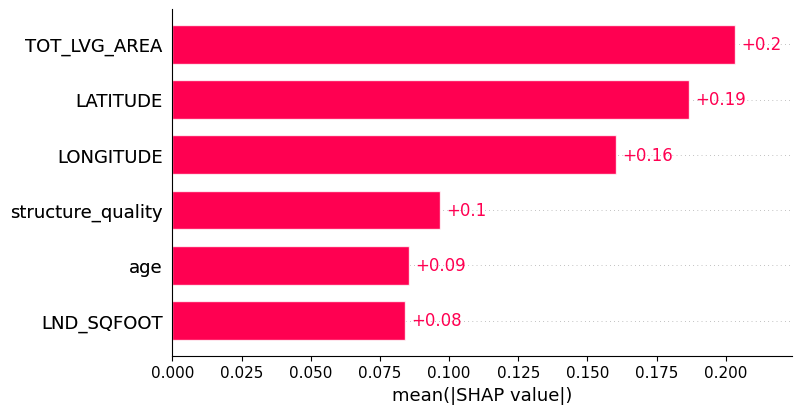

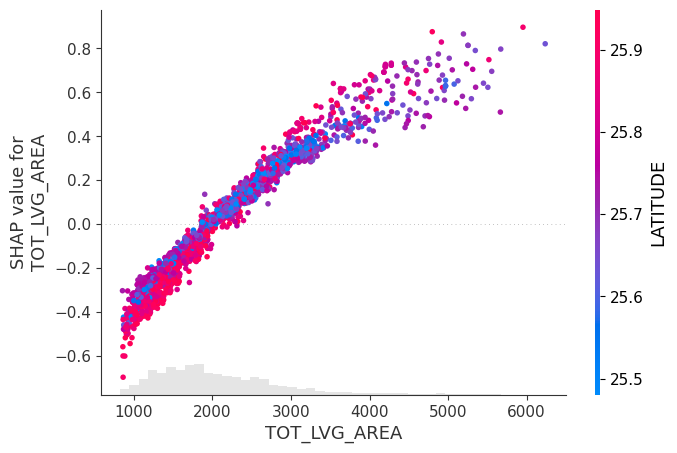

In [8]:
xgb_shap_explainer = shap.Explainer(xgb_model)
xgb_shap_values = xgb_shap_explainer(X_valid)

shap.plots.bar(xgb_shap_values)
shap.plots.scatter(xgb_shap_values[:, "TOT_LVG_AREA"], color=xgb_shap_values)

## TabICL without fine-tuning

Now, we train TabICL on the same data split, using the same features. TabICL has never seen this dataset; it was trained on synthetic tabular data and is used here without any task-specific fine-tuning.

In [9]:
from tabicl import TabICLRegressor

tabicl_model = TabICLRegressor(kv_cache=True, random_state=42)
tabicl_model.fit(X_train, y_train)  # Only data transformation is fitted, not the model

Checkpoint 'tabicl-regressor-v2-20260212.ckpt' not cached.



tabicl-regressor-v2-20260212.ckpt:   0%|          | 0.00/114M [00:00<?, ?B/s]

TabICLRegressor(kv_cache=True)

### Evaluate on the validation data

In [10]:
tabicl_pred = tabicl_model.predict(X_valid)
tabicl_mse = mean_squared_error(y_valid, tabicl_pred)
print(f"TabICL validation RMSE: {np.sqrt(tabicl_mse):.4}")

TabICL validation RMSE: 0.1311


### SHAP analysis

Note that currently, SHAP is used on a single background sample, which is not ideal for tabular data. We also use a smaller explanation data because there is no lightning fast tree SHAP available.

ExactExplainer explainer: 201it [00:34,  4.46it/s]


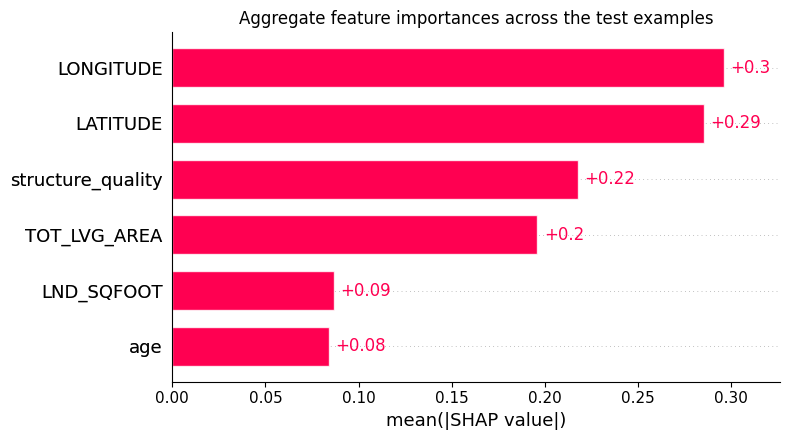

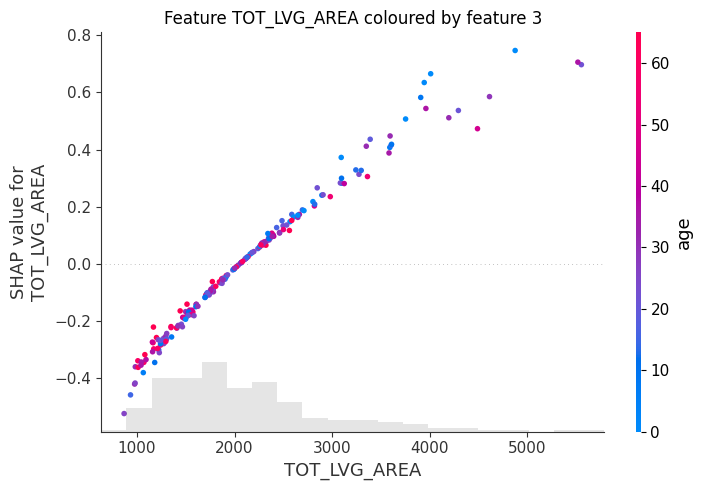

In [11]:
from tabicl.shap import get_shap_values, plot_shap, plot_shap_feature

tabicl_shap_values = get_shap_values(estimator=tabicl_model, X_test=X_valid[:200])
plot_shap(tabicl_shap_values)
plot_shap_feature(tabicl_shap_values, feature="TOT_LVG_AREA")